In [1]:
# CONFIGURATION
import numpy as np
import random

from dotenv import load_dotenv
load_dotenv()

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Paths - must match preprocessing and modeling outputs
TRAIN_PATH = "data/training_scaled.csv"
VAL_PATH = "data/val_scaled.csv"
TEST_PATH = "data/test_scaled.csv"
SCALER_PATH = "artifacts/minmax_scaler.pkl"
PREPROC_PATH = "data/nsrdb_preprocessed.csv"
DAILY_SCALER_PATH = "artifacts/daily_minmax_scaler.pkl"

DAILY_TRAIN_PATH = "data/nsrdb_daily_train.csv"
DAILY_VAL_PATH = "data/nsrdb_daily_val.csv"
DAILY_TEST_PATH = "data/nsrdb_daily_test.csv"
DAILY_TRAIN_SCALED_PATH = "data/daily_train_scaled.csv"
DAILY_VAL_SCALED_PATH = "data/daily_val_scaled.csv"
DAILY_TEST_SCALED_PATH = "data/daily_test_scaled.csv"

LSTM_PATH = "artifacts/lstm_best.keras"
XGB_PATH = "artifacts/xgb_models.pkl"
XGB_DAILY_PATH = "artifacts/xgb_daily_models.pkl"

# Target
TARGET_COL = "ghi"

# Sequence config
WINDOW_SIZE = 24
DAILY_WINDOW = 30
SHORT_HORIZONS = [6,12] # Hourly
MEDIUM_HORIZONS = [7, 14] # Daily
LONG_HORIZONS = [28, 56, 84, 168, 336] # Daily
PROPHET_REGRESSORS = ["temperature", "relative_humidity", "wind_speed", "solar_zenith_angle" , "surface_albedo"]

BATCH_SIZE = 64

import os
os.makedirs("outputs", exist_ok=True)

In [2]:
# IMPORTS
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam

import xgboost as xgb
from prophet import Prophet

print("All importing done")

I0000 00:00:1780275641.779550  257667 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All importing done


In [3]:
# LOAD DATA AND ARTIFACTS
train_scaled = pd.read_csv(TRAIN_PATH, index_col="datetime", parse_dates=True)
val_scaled = pd.read_csv(VAL_PATH, index_col="datetime", parse_dates=True)
test_scaled = pd.read_csv(TEST_PATH, index_col="datetime", parse_dates=True)
df_full = pd.read_csv(PREPROC_PATH, index_col="datetime", parse_dates=True)

scaler = joblib.load(SCALER_PATH)
daily_scaler = joblib.load(DAILY_SCALER_PATH)

daily_train_scaled = pd.read_csv(DAILY_TRAIN_SCALED_PATH, index_col="datetime", parse_dates=True)
daily_val_scaled = pd.read_csv(DAILY_VAL_SCALED_PATH, index_col="datetime", parse_dates=True)
daily_test_scaled = pd.read_csv(DAILY_TEST_SCALED_PATH, index_col="datetime", parse_dates=True)
daily_train_raw = pd.read_csv(DAILY_TRAIN_PATH, index_col="datetime", parse_dates=True)
daily_val_raw = pd.read_csv(DAILY_VAL_PATH, index_col="datetime", parse_dates=True)
daily_test_raw = pd.read_csv(DAILY_TEST_PATH, index_col="datetime", parse_dates=True)

xgb_models = joblib.load(XGB_PATH)
xgb_daily = joblib.load(XGB_DAILY_PATH)

feature_cols = train_scaled.columns.tolist()
target_idx = feature_cols.index(TARGET_COL)
daily_feature_cols = daily_train_scaled.columns.tolist()
daily_target_idx = daily_feature_cols.index(TARGET_COL)

# Reconstruct unscaled test split (same 70/15/15 boundary)
n = len(df_full)
df_train_raw = df_full.iloc[:int(n * .70)]
df_val_raw = df_full.iloc[int(n * .70):int(n * .85)]
df_test_raw = df_full.iloc[int(n * .85):]

PEAK_GHI = df_full[TARGET_COL].max()
RMSE_TARGET = PEAK_GHI * 0.10

# LSTM architecture
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DROPOUT_RATE = .2
DENSE_UNITS = 32

print(f"\nTest rows (hourly): {len(test_scaled):,}")
print(f"Test rows (daily): {len(daily_test_scaled):,}")
print(f"Peak GHI: {PEAK_GHI:.1f} W/m^2")
print(f"10% RMSE target: {RMSE_TARGET:.1f} W/m^2")


Test rows (hourly): 13,151
Test rows (daily): 548
Peak GHI: 990.0 W/m^2
10% RMSE target: 99.0 W/m^2


In [4]:
# SHARED UTILITIES
def build_sequences(data, window, horizons, tgt_idx):
    # Sliding window builder
    # Returns X (3D) and y_dict {horizon: 1D array}
    X, ys = [], {h: [] for h in horizons}
    max_h = max(horizons)
    for i in range(window, len(data) - max_h + 1):
        X.append(data[i - window: i, :])
        for h in horizons:
            ys[h].append(data[i + h - 1, tgt_idx])
    return np.array(X), {h: np.array(v) for h, v in ys.items()}

def inverse_ghi(scaled_arr, sc, feat_cols, tgt_col="ghi"):
    # Inverse transform a 1D scaled GHI array back to W/m^2.
    tgt_i = feat_cols.index(tgt_col)
    dummy = np.zeros((len(scaled_arr), len(feat_cols)))
    dummy[:, tgt_i] = scaled_arr
    return sc.inverse_transform(dummy)[:, tgt_i]


def regression_metrics(y_true, y_pred):
    # Return MAE, RMSE, R^2, MAPE (daytime only)
    # All W/m^2 except MAPE (%)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 1 # exclude nighttime zeros to avoid divide by zero
    mape = (
        np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        if mask.sum() > 0 else np.nan
    )
    return {"MAE (W/m^2)": mae, "RMSE (W/m^2)": rmse, "R^2": r2, "MAPE (%)": mape}

In [5]:
# BUILD HOURLY TEST SEQUENCES
test_arr = test_scaled.values
X_test, y_test = build_sequences(test_arr, WINDOW_SIZE, SHORT_HORIZONS, target_idx)
print(f"\nX_test shape: {X_test.shape}")
print(f"Samples per horizon: {len(y_test[SHORT_HORIZONS[0]]):,}")


X_test shape: (13116, 24, 17)
Samples per horizon: 13,116


In [6]:
# LSTM PREDICTIONS
print("\nLSTM")

# Rebuild architecture with use_cudnn=False (same as modeling.ipynb) then load weights from the saved artifact - avoids CuDNN at inference
def build_lstm(window, n_features, n_outputs):
    model = Sequential([
        Input(shape=(window, n_features)),
        LSTM(LSTM_UNITS_1, return_sequences=True, use_cudnn=False),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS_2, return_sequences=False, use_cudnn=False),
        Dropout(DROPOUT_RATE),
        Dense(DENSE_UNITS, activation="relu"),
        Dense(n_outputs)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

lstm_model = build_lstm(WINDOW_SIZE, X_test.shape[2], len(SHORT_HORIZONS))
lstm_model.load_weights(LSTM_PATH)

lstm_pred_scaled = lstm_model.predict(X_test, verbose=0, batch_size=BATCH_SIZE)

lstm_results = {}
for i, h in enumerate(SHORT_HORIZONS):
    pred_inv = inverse_ghi(lstm_pred_scaled[:, i], scaler, feature_cols)
    true_inv = inverse_ghi(y_test[h], scaler, feature_cols)
    lstm_results[h] = {"pred": pred_inv, "true": true_inv, **regression_metrics(true_inv, pred_inv)}
    r = lstm_results[h]
    print(f"h={h:2d}h | RMSE={r['RMSE (W/m^2)']:7.2f} MAE={r['MAE (W/m^2)']:7.2f} R^2={r['R^2']:.4f} MAPE={r['MAPE (%)']:.2f}%")


LSTM


h= 6h | RMSE=  90.68 MAE=  44.41 R^2=0.8637 MAPE=75.96%
h=12h | RMSE=  98.02 MAE=  47.71 R^2=0.8404 MAPE=80.42%


In [7]:
# XGBOOST SHORT HORIZON PREDICTIONS
print("\nXGBoost (hourly)")
X_test_flat = X_test.reshape(X_test.shape[0], -1)

xgb_results = {}
for h in SHORT_HORIZONS:
    pred_scaled = xgb_models[h].predict(X_test_flat)
    pred_inv = inverse_ghi(pred_scaled, scaler, feature_cols)
    true_inv = inverse_ghi(y_test[h], scaler, feature_cols)
    xgb_results[h] = {"pred": pred_inv, "true": true_inv, **regression_metrics(true_inv, pred_inv)}
    r = xgb_results[h]
    print(f"h={h:2d}h | RMSE={r['RMSE (W/m^2)']:7.2f} MAE={r['MAE (W/m^2)']:7.2f} R^2={r['R^2']:.4f} MAPE={r['MAPE (%)']:.2f}%")


XGBoost (hourly)
h= 6h | RMSE=  88.14 MAE=  44.64 R^2=0.8712 MAPE=72.85%
h=12h | RMSE=  93.40 MAE=  47.63 R^2=0.8551 MAPE=77.44%


In [8]:
# PROPHET SHORT HORIZON PREDICTIONS
print("\nProphet (hourly)")
prophet_models = {h: joblib.load(f"artifacts/prophet_h{h}.pkl") for h in SHORT_HORIZONS}

prophet_results = {}
for h in SHORT_HORIZONS:
    test_prophet = df_test_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    test_prophet["ds"] = test_prophet.index
    test_prophet["y"] = test_prophet[TARGET_COL].shift(-h)
    test_prophet = test_prophet.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    forecast = prophet_models[h].predict(test_prophet[["ds"] + PROPHET_REGRESSORS])
    pred = np.clip(forecast["yhat"].values, 0, None)
    true = test_prophet["y"].values

    prophet_results[h] = {"pred": pred, "true": true, **regression_metrics(true, pred)}
    r = prophet_results[h]
    print(f"h={h:2d}h | RMSE={r['RMSE (W/m^2)']:7.2f} MAE={r['MAE (W/m^2)']:7.2f} R^2={r['R^2']:.4f} MAPE={r['MAPE (%)']:.2f}%")


Prophet (hourly)


h= 6h | RMSE= 158.61 MAE=  89.52 R^2=0.5829 MAPE=135.20%


h=12h | RMSE= 153.96 MAE=  86.75 R^2=0.6067 MAPE=134.83%


In [9]:
# XGBOOST MEDIUM HORIZON PREDICTIONS
print("\nXGBoost (daily, medium horizon)")
daily_test_arr = daily_test_scaled.values
X_daily_test, y_daily_test = build_sequences(daily_test_arr, DAILY_WINDOW, MEDIUM_HORIZONS, daily_target_idx)
X_daily_test_flat = X_daily_test.reshape(X_daily_test.shape[0], -1)

xgb_daily_results = {}
for h in MEDIUM_HORIZONS:
    pred_scaled = xgb_daily[h].predict(X_daily_test_flat)
    pred_inv = inverse_ghi(pred_scaled, daily_scaler, daily_feature_cols)
    true_inv = inverse_ghi(y_daily_test[h], daily_scaler, daily_feature_cols)
    xgb_daily_results[h] = {"pred": pred_inv, "true": true_inv, **regression_metrics(true_inv, pred_inv)}
    r = xgb_daily_results[h]
    print(f"h={h:2d}d | RMSE={r['RMSE (W/m^2)']:7.2f} MAE={r['MAE (W/m^2)']:7.2f} R^2={r['R^2']:.4f} MAPE={r['MAPE (%)']:.2f}%")


XGBoost (daily, medium horizon)
h= 7d | RMSE=1376.30 MAE=1026.64 R^2=0.6507 MAPE=54.10%
h=14d | RMSE=1322.58 MAE= 988.04 R^2=0.6770 MAPE=53.11%


In [10]:
# PROPHET LONG HORIZON PREDICTIONS
print("\nProphet (daily, long horizon)")
prophet_long_results = {}
for h in LONG_HORIZONS:
    m = joblib.load(f"artifacts/prophet_long_h{h}d.pkl")
    cols = [TARGET_COL] + PROPHET_REGRESSORS

    test_df_p = daily_test_raw[cols].copy()
    test_df_p["y"] = test_df_p[TARGET_COL].shift(-h)
    test_df_p["ds"] = test_df_p.index
    test_df_p = test_df_p.dropna()[["ds", "y"] + PROPHET_REGRESSORS]

    forecast = m.predict(test_df_p[["ds"] + PROPHET_REGRESSORS])
    pred = np.clip(forecast["yhat"].values, 0, None)
    true = test_df_p["y"].values
    weeks = h // 7

    prophet_long_results[h] = {"pred": pred, "true": true, "label": f"{weeks}w", **regression_metrics(true, pred)}
    r = prophet_long_results[h]
    print(f"h={h:3d}d ({weeks:2d}w) | RMSE={r['RMSE (W/m^2)']:7.2f} MAE={r['MAE (W/m^2)']:7.2f} R^2={r['R^2']:.4f} MAPE={r['MAPE (%)']:.2f}%")


Prophet (daily, long horizon)
h= 28d ( 4w) | RMSE=1399.54 MAE= 970.77 R^2=0.6410 MAPE=54.49%
h= 56d ( 8w) | RMSE=1337.97 MAE= 946.93 R^2=0.6670 MAPE=53.39%
h= 84d (12w) | RMSE=1326.83 MAE= 948.80 R^2=0.6794 MAPE=52.68%


h=168d (24w) | RMSE=1449.34 MAE= 984.07 R^2=0.6424 MAPE=52.52%


h=336d (48w) | RMSE=1383.59 MAE= 917.66 R^2=0.6937 MAPE=43.68%


In [11]:
# THREE MODEL COMPARISON TABLE
print("THREE MODEL SIDE-BY-SIDE COMPARISON (held out test set)")

rows = []
for h in SHORT_HORIZONS:
    for model_name, results in [("LSTM", lstm_results),("XGBoost", xgb_results),("Prophet", prophet_results)]:
        r = results[h]
        rows.append({
            "Horizon": f"{h}h ahead",
            "Model": model_name,
            "MAE (W/m^2)": round(r["MAE (W/m^2)"], 2),
            "RMSE (W/m^2)": round(r["RMSE (W/m^2)"], 2),
            "R^2": round(r["R^2"], 4),
            "MAPE (%)": round(r["MAPE (%)"], 2),
        })

comparison_df = pd.DataFrame(rows).set_index(["Horizon", "Model"])
print(comparison_df.to_string())

print(f"\nRMSE Target Check (<={RMSE_TARGET:.1f} W/m^2 = 10% of peak GHI {PEAK_GHI:.1f} W/m^2)")
for h in SHORT_HORIZONS:
    for name, res in [("LSTM", lstm_results), ("XGBoost", xgb_results), ("Prophet", prophet_results)]:
        rmse = res[h]["RMSE (W/m^2)"]
        status = "PASS" if rmse <= RMSE_TARGET else "FAIL"
        print(f"{name:8s} h={h}h: RMSE={rmse:.2f} W/m^2 {status}")

THREE MODEL SIDE-BY-SIDE COMPARISON (held out test set)
                   MAE (W/m^2)  RMSE (W/m^2)     R^2  MAPE (%)
Horizon   Model                                               
6h ahead  LSTM           44.41         90.68  0.8637     75.96
          XGBoost        44.64         88.14  0.8712     72.85
          Prophet        89.52        158.61  0.5829    135.20
12h ahead LSTM           47.71         98.02  0.8404     80.42
          XGBoost        47.63         93.40  0.8551     77.44
          Prophet        86.75        153.96  0.6067    134.83

RMSE Target Check (<=99.0 W/m^2 = 10% of peak GHI 990.0 W/m^2)
LSTM     h=6h: RMSE=90.68 W/m^2 PASS
XGBoost  h=6h: RMSE=88.14 W/m^2 PASS
Prophet  h=6h: RMSE=158.61 W/m^2 FAIL
LSTM     h=12h: RMSE=98.02 W/m^2 PASS
XGBoost  h=12h: RMSE=93.40 W/m^2 PASS
Prophet  h=12h: RMSE=153.96 W/m^2 FAIL


In [12]:
# MEDIUM/LONG HORIZON SUMMARY TABLE
print("MEDIUM/LONG HORIZON SUMMARY")

long_rows = []
for h in MEDIUM_HORIZONS:
    r = xgb_daily_results[h]
    long_rows.append({
        "Horizon": f"{h}d ahead", "Model": "XGBoost (daily)",
        "MAE (Wh/m^2)": round(r["MAE (W/m^2)"], 1),
        "RMSE (Wh/m^2)": round(r["RMSE (W/m^2)"], 1),
        "R^2": round(r["R^2"], 4),
        "MAPE (%)": round(r["MAPE (%)"], 2),
    })
for h in LONG_HORIZONS:
    r = prophet_long_results[h]
    long_rows.append({
        "Horizon": f"{r['label']} ({h}d)", "Model": "Prophet (daily)",
        "MAE (Wh/m^2)": round(r["MAE (W/m^2)"], 1),
        "RMSE (Wh/m^2)": round(r["RMSE (W/m^2)"], 1),
        "R^2": round(r["R^2"], 4),
        "MAPE (%)": round(r["MAPE (%)"], 2),
    })

long_df = pd.DataFrame(long_rows).set_index(["Horizon", "Model"])
print(long_df.to_string())
print("\nNote: Long horizon totals are derived aggregates. Error accumulation with horizon length is expected and documented (proposal Risk 5).")

MEDIUM/LONG HORIZON SUMMARY
                            MAE (Wh/m^2)  RMSE (Wh/m^2)     R^2  MAPE (%)
Horizon    Model                                                         
7d ahead   XGBoost (daily)        1026.6         1376.3  0.6507     54.10
14d ahead  XGBoost (daily)         988.0         1322.6  0.6770     53.11
4w (28d)   Prophet (daily)         970.8         1399.5  0.6410     54.49
8w (56d)   Prophet (daily)         946.9         1338.0  0.6670     53.39
12w (84d)  Prophet (daily)         948.8         1326.8  0.6794     52.68
24w (168d) Prophet (daily)         984.1         1449.3  0.6424     52.52
48w (336d) Prophet (daily)         917.7         1383.6  0.6937     43.68

Note: Long horizon totals are derived aggregates. Error accumulation with horizon length is expected and documented (proposal Risk 5).


In [13]:
# SAVE METRICS TO CSV
comparison_df.to_csv("outputs/metrics_short_horizon.csv")
long_df.to_csv("outputs/metrics_long_horizon.csv")
print("\nSaved to outputs/metrics_short_horizon.csv")
print("Saved to outputs/metrics_long_horizon.csv")


Saved to outputs/metrics_short_horizon.csv
Saved to outputs/metrics_long_horizon.csv


In [14]:
# PLOT HELPERS
MODEL_COLORS = {"LSTM": "#2196F3", "XGBoost": "#FF9800", "Prophet": "#4CAF50"}
LEGEND_PATCHES = [
    mpatches.Patch(facecolor=MODEL_COLORS["LSTM"], label="LSTM"),
    mpatches.Patch(facecolor=MODEL_COLORS["XGBoost"], label="XGBoost"),
    mpatches.Patch(facecolor=MODEL_COLORS["Prophet"], label="Prophet"),
]

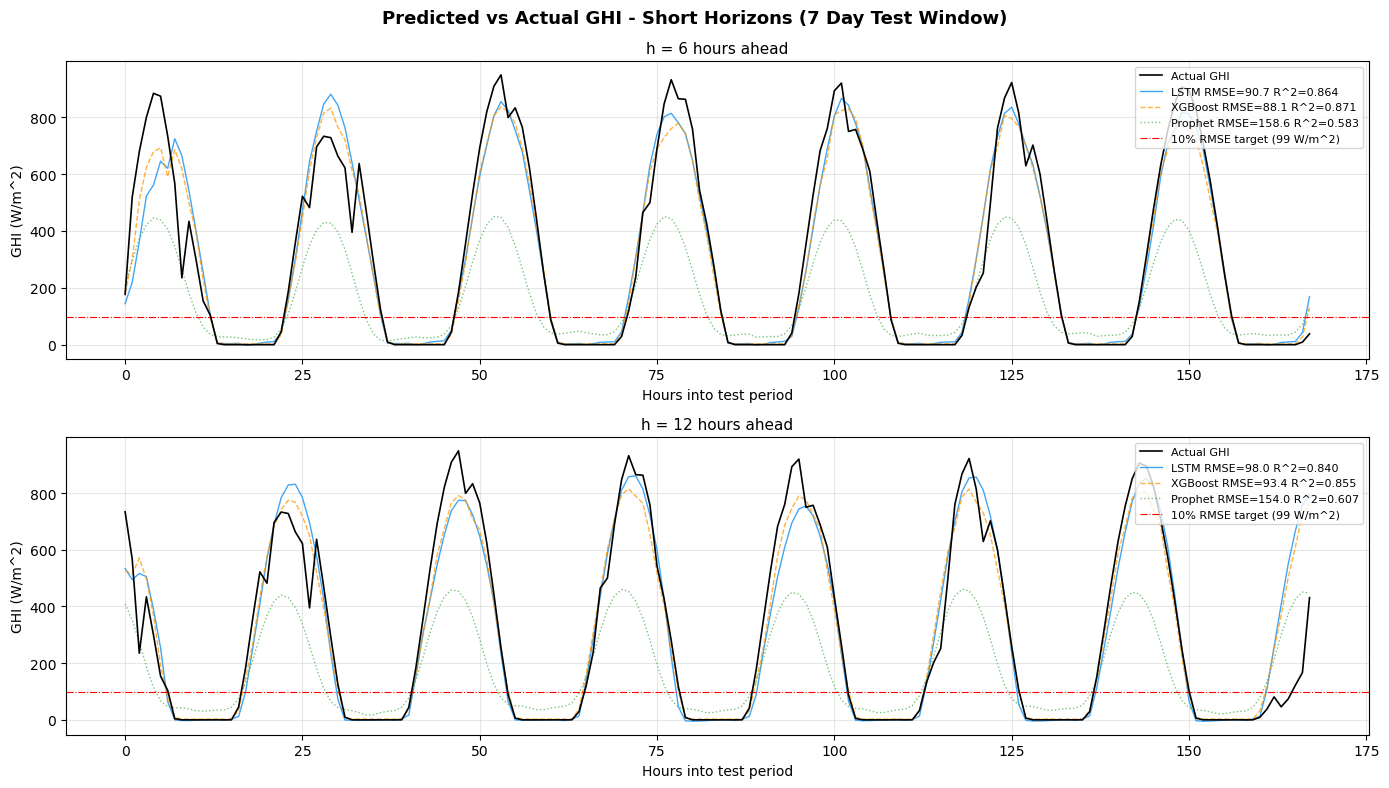

Saved to outputs/plot1_timeseries_short_horizon.png


In [15]:
# PLOT 1: TIME SERIES OVERLAY - SHORT HORIZONS
# Shows a 7 day window from the test period with all three models overlaid.
# RMSE and R^2 for each model are shown in the legend.
PLOT_HOURS = 168    # 7 days

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle("Predicted vs Actual GHI - Short Horizons (7 Day Test Window)", fontsize=13, fontweight="bold")

for ax, h in zip(axes, SHORT_HORIZONS):
    n_plot = min(PLOT_HOURS, len(lstm_results[h]["true"]))
    x = np.arange(n_plot)

    ax.plot(x, lstm_results[h]["true"][:n_plot], color="black", linewidth=1.2, label="Actual GHI", zorder=3)
    ax.plot(x, lstm_results[h]["pred"][:n_plot], color=MODEL_COLORS["LSTM"], linewidth=1.0, alpha=0.85, label=f"LSTM RMSE={lstm_results[h]['RMSE (W/m^2)']:.1f} R^2={lstm_results[h]['R^2']:.3f}")
    ax.plot(x, xgb_results[h]["pred"][:n_plot], color=MODEL_COLORS["XGBoost"], linewidth=1.0, alpha=0.75, linestyle="--", label=f"XGBoost RMSE={xgb_results[h]['RMSE (W/m^2)']:.1f} R^2={xgb_results[h]['R^2']:.3f}")
    ax.plot(x, prophet_results[h]["pred"][:n_plot], color=MODEL_COLORS["Prophet"], linewidth=1.0, alpha=0.75, linestyle=":", label=f"Prophet RMSE={prophet_results[h]['RMSE (W/m^2)']:.1f} R^2={prophet_results[h]['R^2']:.3f}")
    ax.axhline(RMSE_TARGET, color="red", linewidth=0.8, linestyle="-.", label=f"10% RMSE target ({RMSE_TARGET:.0f} W/m^2)")

    ax.set_title(f"h = {h} hours ahead", fontsize=11)
    ax.set_ylabel("GHI (W/m^2)")
    ax.set_xlabel("Hours into test period")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plot1_timeseries_short_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot1_timeseries_short_horizon.png")

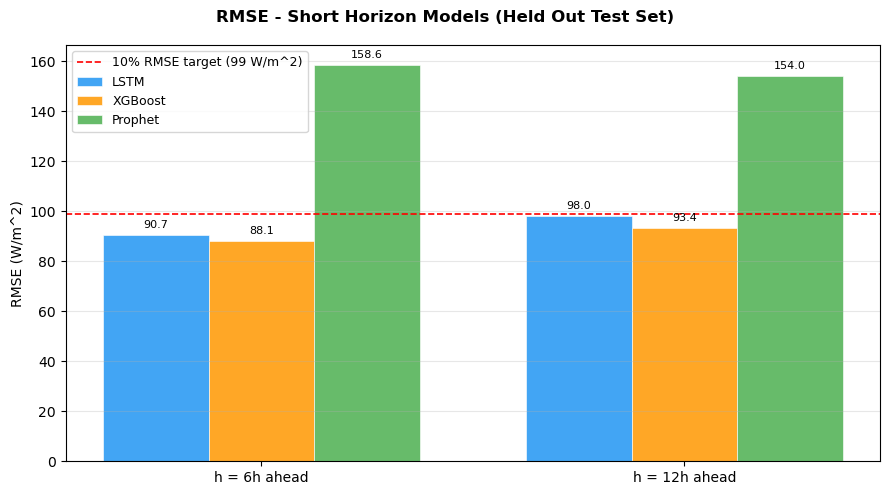

Saved to outputs/plot2_rmse_short_horizon.png


In [16]:
# PLOT 2: RMSE COMPARISON - SHORT HORIZONS
# Side-by-side bars for all three models at each short horizon.
# Red dashed line marks the 10% peak GHI RMSE target.
model_specs = [
    ("LSTM", lstm_results, MODEL_COLORS["LSTM"]),
    ("XGBoost", xgb_results, MODEL_COLORS["XGBoost"]),
    ("Prophet", prophet_results, MODEL_COLORS["Prophet"]),
]

n_models = len(model_specs)
bar_width = 0.25
x = np.arange(len(SHORT_HORIZONS))

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("RMSE - Short Horizon Models (Held Out Test Set)", fontsize=12, fontweight="bold")

for i, (name, results, color) in enumerate(model_specs):
    rmses = [results[h]["RMSE (W/m^2)"] for h in SHORT_HORIZONS]
    offset = (i - (n_models - 1) / 2) * bar_width
    bars = ax.bar(x + offset, rmses, width=bar_width, color=color, alpha=0.85, edgecolor="white", linewidth=0.5, label=name)
    for bar, val in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

ax.axhline(RMSE_TARGET, color="red", linewidth=1.2, linestyle="--", label=f"10% RMSE target ({RMSE_TARGET:.0f} W/m^2)")
ax.set_xticks(x)
ax.set_xticklabels([f"h = {h}h ahead" for h in SHORT_HORIZONS])
ax.set_ylabel("RMSE (W/m^2)")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/plot2_rmse_short_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot2_rmse_short_horizon.png")

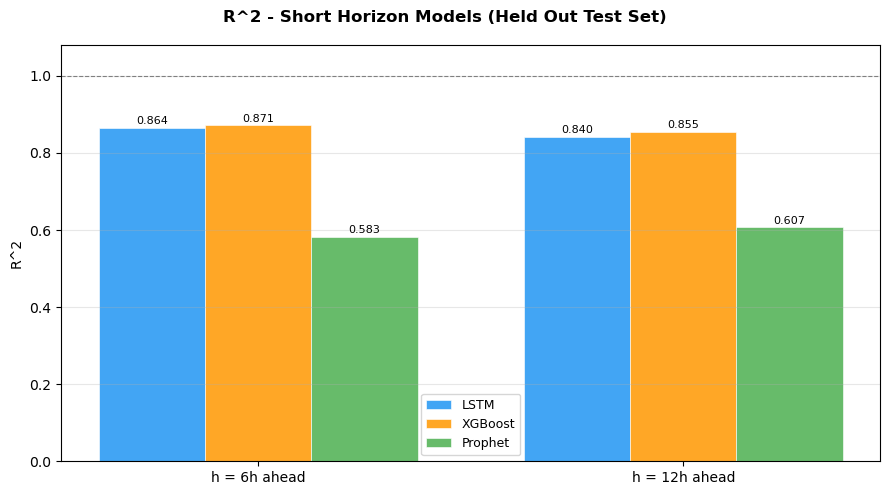

Saved to outputs/plot3_r2_short_horizon.png


In [17]:
# PLOT 3: R^2 COMPARISON - SHORT HORIZONS
# Mirrors Plot 2 layout; higher is better, perfect prediction = 1.0.
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("R^2 - Short Horizon Models (Held Out Test Set)", fontsize=12, fontweight="bold")

for i, (name, results, color) in enumerate(model_specs):
    r2s = [results[h]["R^2"] for h in SHORT_HORIZONS]
    offset = (i - (n_models - 1) / 2) * bar_width
    bars = ax.bar(x + offset, r2s, width=bar_width, color=color, alpha=0.85, edgecolor="white", linewidth=0.5, label=name)
    for bar, val in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.3f}", ha="center", va="bottom", fontsize=8)

all_r2 = [results[h]["R^2"] for _, results, _ in model_specs for h in SHORT_HORIZONS]
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(min(0, min(all_r2) - 0.05), 1.08)
ax.set_xticks(x)
ax.set_xticklabels([f"h = {h}h ahead" for h in SHORT_HORIZONS])
ax.set_ylabel("R^2")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/plot3_r2_short_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot3_r2_short_horizon.png")

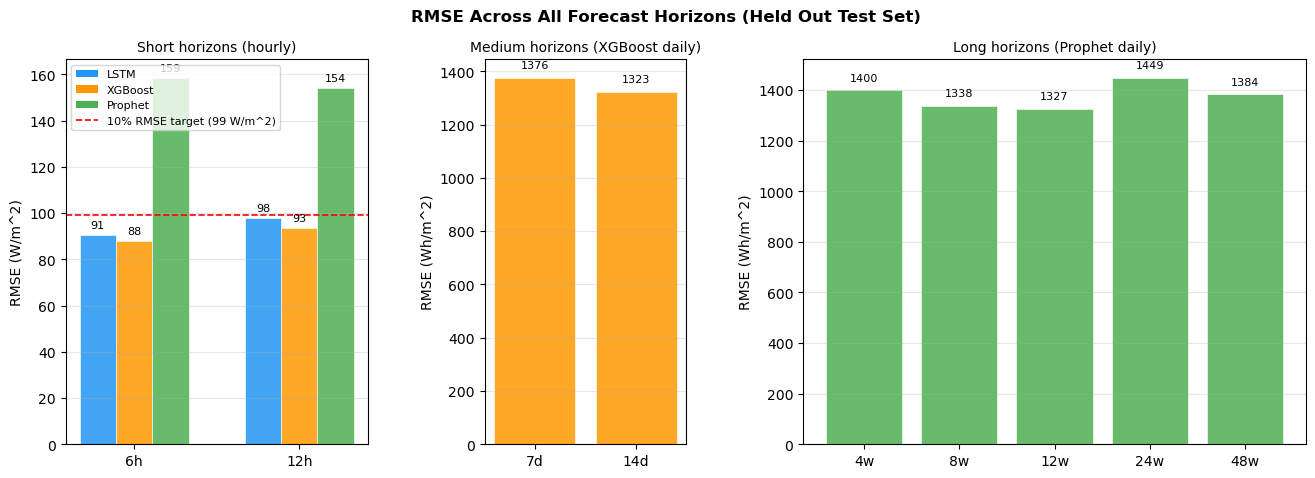

Saved to outputs/plot4_rmse_all_horizons.png


In [18]:
# PLOT 4: RMSE BAR CHART - ALL HORIZONS
# Short horizons show all three models side-by-side.
# Medium and long horizons show the single model used for each range.
fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 2, 5], "wspace": 0.35})
fig.suptitle("RMSE Across All Forecast Horizons (Held Out Test Set)", fontsize=12, fontweight="bold")

# Short horizons
ax = axes[0]
bw = 0.22
xs = np.arange(len(SHORT_HORIZONS))
for i, (name, results, color) in enumerate(model_specs):
    rmses = [results[h]["RMSE (W/m^2)"] for h in SHORT_HORIZONS]
    bars = ax.bar(xs + (i - 1) * bw, rmses, width=bw, color=color, alpha=0.85, edgecolor="white", linewidth=0.5, label=name)
    for bar, val in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
ax.axhline(RMSE_TARGET, color="red", linewidth=1.2, linestyle="--", label=f"10% RMSE target ({RMSE_TARGET:.0f} W/m^2)")
ax.set_xticks(xs)
ax.set_xticklabels([f"{h}h" for h in SHORT_HORIZONS])
ax.set_title("Short horizons (hourly)", fontsize=10)
ax.set_ylabel("RMSE (W/m^2)")
ax.legend(handles=LEGEND_PATCHES + [plt.Line2D([0], [0], color="red", linewidth=1.2, linestyle="--", label=f"10% RMSE target ({RMSE_TARGET:.0f} W/m^2)")], fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# Medium horizons
ax = axes[1]
med_labels = [f"{h}d" for h in MEDIUM_HORIZONS]
med_rmses = [xgb_daily_results[h]["RMSE (W/m^2)"] for h in MEDIUM_HORIZONS]
bars = ax.bar(med_labels, med_rmses, color=MODEL_COLORS["XGBoost"], alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, med_rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(med_rmses) * 0.02, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Medium horizons (XGBoost daily)", fontsize=10)
ax.set_ylabel("RMSE (Wh/m^2)")
ax.grid(True, axis="y", alpha=0.3)

# Long horizons
ax = axes[2]
long_labels = [f"{h // 7}w" for h in LONG_HORIZONS]
long_rmses = [prophet_long_results[h]["RMSE (W/m^2)"] for h in LONG_HORIZONS]
bars = ax.bar(long_labels, long_rmses, color=MODEL_COLORS["Prophet"], alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, long_rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(long_rmses) * 0.02, f"{val:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_title("Long horizons (Prophet daily)", fontsize=10)
ax.set_ylabel("RMSE (Wh/m^2)")
ax.grid(True, axis="y", alpha=0.3)

plt.savefig("outputs/plot4_rmse_all_horizons.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot4_rmse_all_horizons.png")

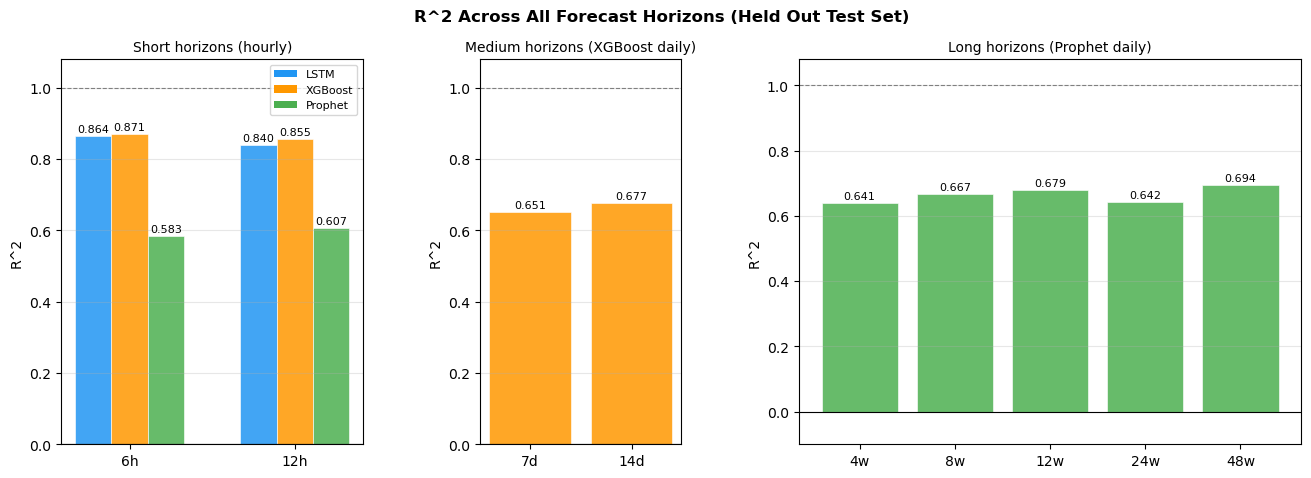

Saved to outputs/plot5_r2_all_horizons.png


In [19]:
# PLOT 5: R^2 BAR CHART - ALL HORIZONS
# R^2 is the regression analog of "accuracy".
# Values near 1.0 indicate the model explains most GHI variance.
# Negative values indicate the model is worse than predicting the mean - expected for very long horizons.

fig, axes = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 2, 5], "wspace": 0.35})
fig.suptitle("R^2 Across All Forecast Horizons (Held Out Test Set)", fontsize=12, fontweight="bold")

# Short horizons
ax = axes[0]
bw = 0.22
xs = np.arange(len(SHORT_HORIZONS))
for i, (name, results, color) in enumerate(model_specs):
    r2s = [results[h]["R^2"] for h in SHORT_HORIZONS]
    bars = ax.bar(xs + (i - 1) * bw, r2s, width=bw, color=color, alpha=0.85, edgecolor="white", linewidth=0.5, label=name)
    for bar, val in zip(bars, r2s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
all_short_r2 = [results[h]["R^2"] for _, results, _ in model_specs for h in SHORT_HORIZONS]
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(min(0, min(all_short_r2) - 0.05), 1.08)
ax.set_xticks(xs)
ax.set_xticklabels([f"{h}h" for h in SHORT_HORIZONS])
ax.set_title("Short horizons (hourly)", fontsize=10)
ax.set_ylabel("R^2")
ax.legend(handles=LEGEND_PATCHES, fontsize=8)
ax.grid(True, axis="y", alpha=0.3)

# Medium horizons
ax = axes[1]
med_labels = [f"{h}d" for h in MEDIUM_HORIZONS]
med_r2s = [xgb_daily_results[h]["R^2"] for h in MEDIUM_HORIZONS]
bars = ax.bar(med_labels, med_r2s, color=MODEL_COLORS["XGBoost"], alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, med_r2s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(min(0, min(med_r2s) - 0.05), 1.08)
ax.set_title("Medium horizons (XGBoost daily)", fontsize=10)
ax.set_ylabel("R^2")
ax.grid(True, axis="y", alpha=0.3)

# Long horizons
ax = axes[2]
long_labels = [f"{h // 7}w" for h in LONG_HORIZONS]
long_r2s = [prophet_long_results[h]["R^2"] for h in LONG_HORIZONS]
bars = ax.bar(long_labels, long_r2s, color=MODEL_COLORS["Prophet"], alpha=0.85, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, long_r2s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.005 if val >= 0 else -0.04), f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(min(-0.1, min(long_r2s) - 0.05), 1.08)
ax.set_title("Long horizons (Prophet daily)", fontsize=10)
ax.set_ylabel("R^2")
ax.grid(True, axis="y", alpha=0.3)

plt.savefig("outputs/plot5_r2_all_horizons.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot5_r2_all_horizons.png")

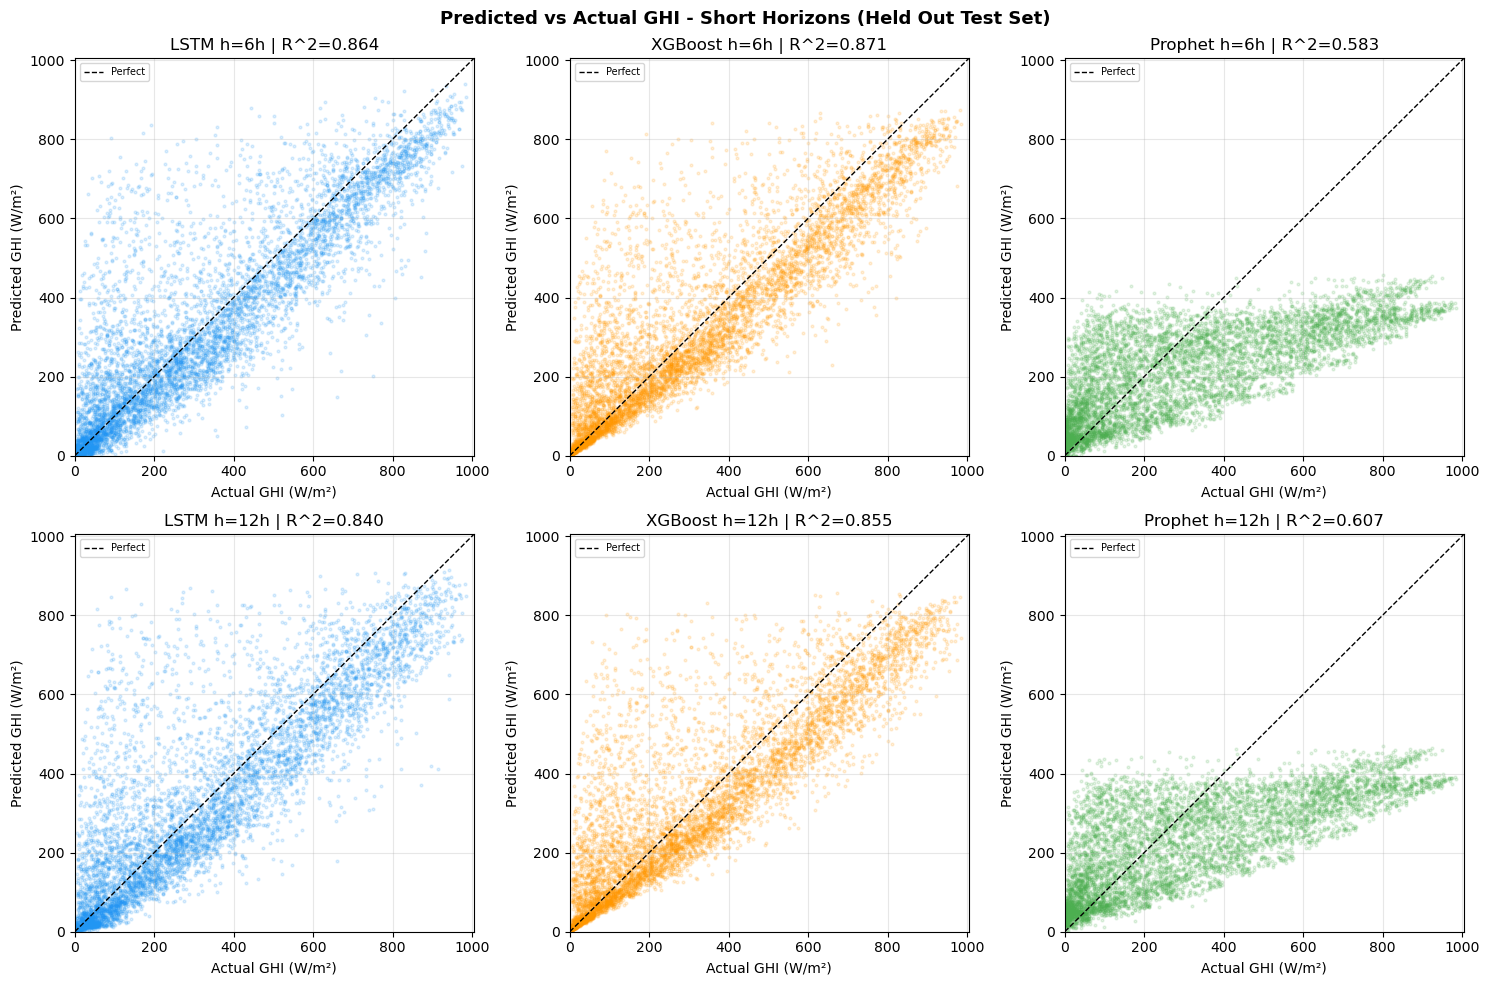

Saved to outputs/plot6_scatter_short_horizon.png


In [20]:
# PLOT 6: PREDICTED VS ACTUAL SCATTER - SHORT HORIZONS
# Daytime points only (GHI > 1 W/m^2) so nighttime zeros don't dominate.
# The 1:1 line marks perfect prediction. Tight cluster along it = good tracking.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Predicted vs Actual GHI - Short Horizons (Held Out Test Set)", fontsize=13, fontweight="bold")

for row, h in enumerate(SHORT_HORIZONS):
    for col, (name, results, color) in enumerate(model_specs):
        ax = axes[row][col]
        true = results[h]["true"]
        pred = results[h]["pred"]

        mask = true > 1  # daytime only
        ax.scatter(true[mask], pred[mask], alpha=0.15, s=4, color=color)

        lim = max(true.max(), pred.max()) * 1.02
        ax.plot([0, lim], [0, lim], color="black", linewidth=1.0, linestyle="--", label="Perfect")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Actual GHI (W/m\u00b2)")
        ax.set_ylabel("Predicted GHI (W/m\u00b2)")
        ax.set_title(f"{name} h={h}h | R^2={results[h]['R^2']:.3f}")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plot6_scatter_short_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot6_scatter_short_horizon.png")

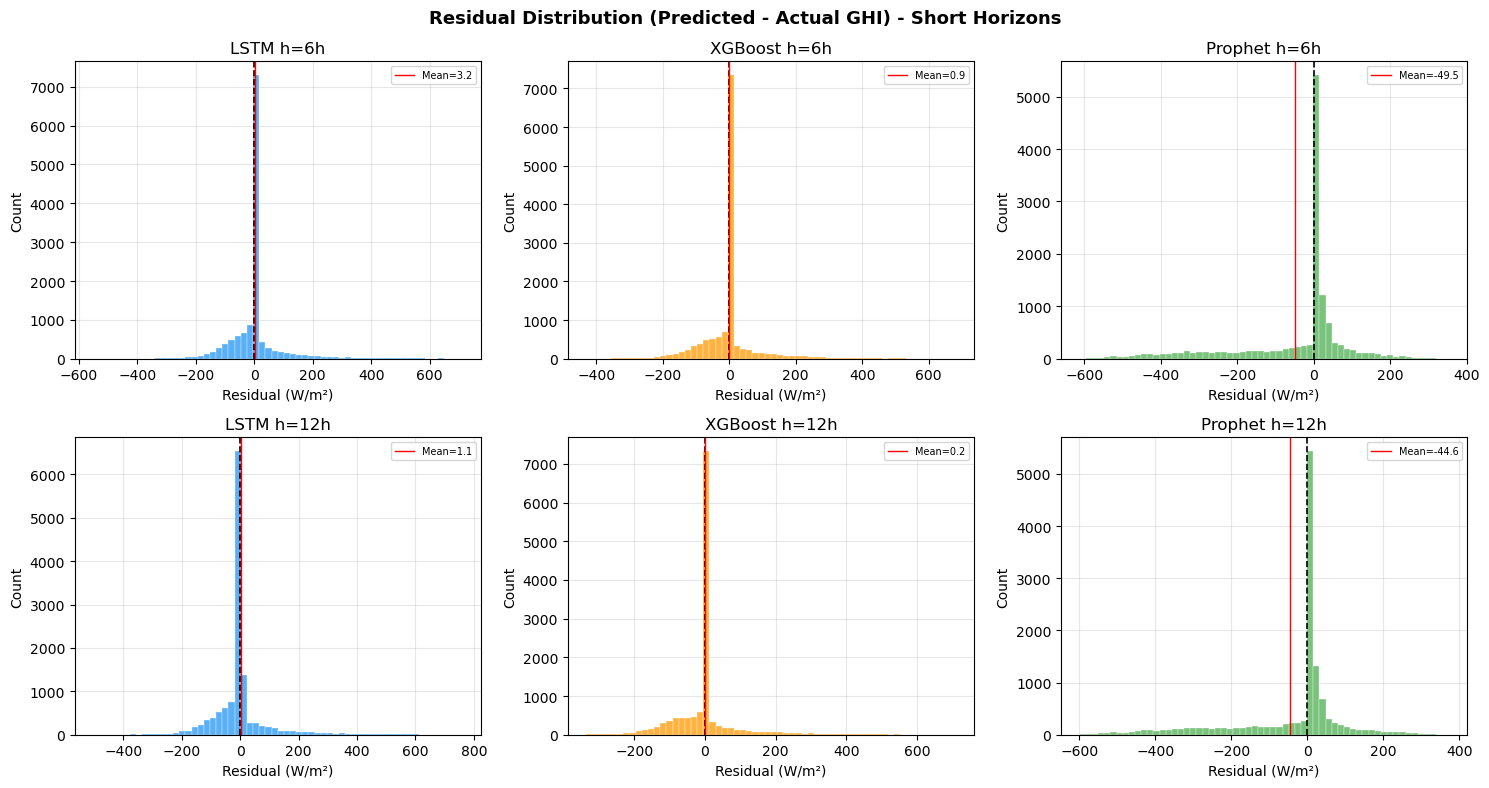

Saved to outputs/plot7_residuals_short_horizon.png


In [21]:
# PLOT 7: RESIDUAL DISTRIBUTION - SHORT HORIZONS
# Histogram of (predicted - actual) for each model and horizon.
# Centered at 0 = unbiased. Positive skew = over-predicting. Negative skew = under-predicting.
# Red line marks the mean residual.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Residual Distribution (Predicted - Actual GHI) - Short Horizons", fontsize=13, fontweight="bold")

for row, h in enumerate(SHORT_HORIZONS):
    for col, (name, results, color) in enumerate(model_specs):
        ax = axes[row][col]
        residuals = results[h]["pred"] - results[h]["true"]

        ax.hist(residuals, bins=60, color=color, alpha=0.75, edgecolor="white", linewidth=0.3)
        ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
        ax.axvline(residuals.mean(), color="red", linewidth=1.0, linestyle="-", label=f"Mean={residuals.mean():.1f}")
        ax.set_xlabel("Residual (W/m\u00b2)")
        ax.set_ylabel("Count")
        ax.set_title(f"{name} h={h}h")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/plot7_residuals_short_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot7_residuals_short_horizon.png")

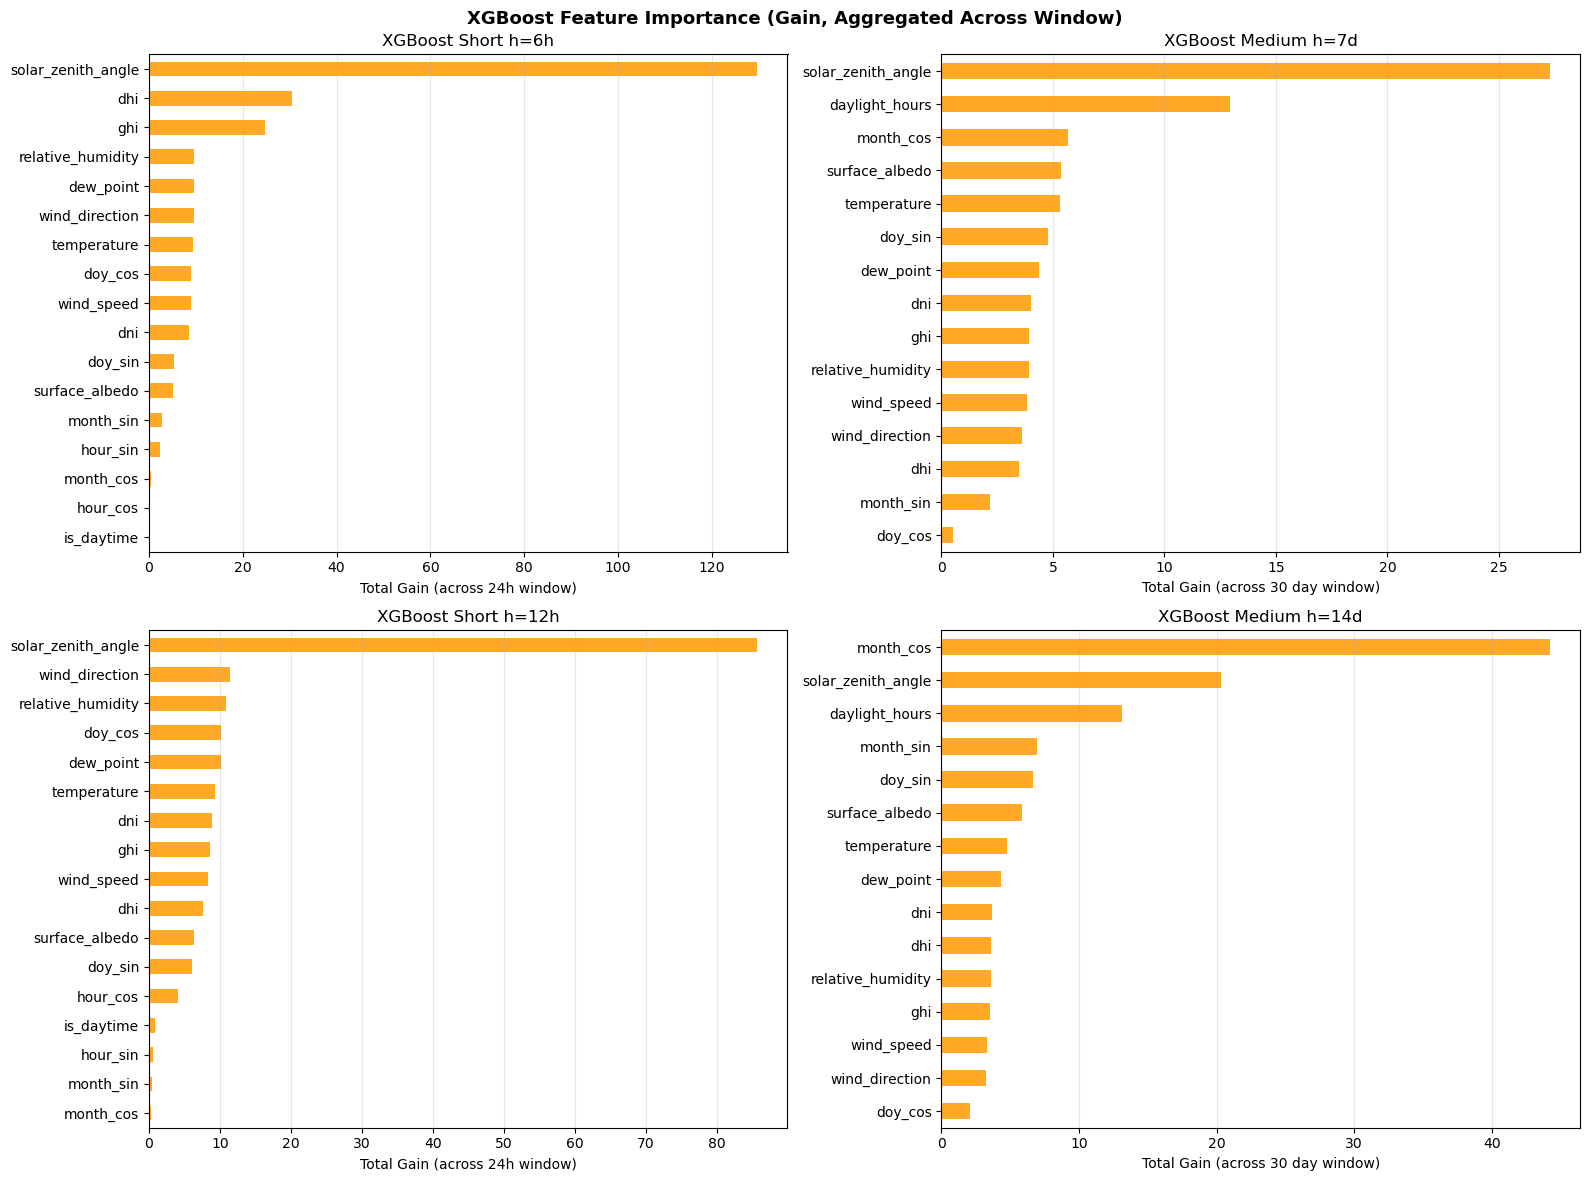

Saved to outputs/plot8_xgb_feature_importance.png


In [22]:
# PLOT 8: XGBOOST FEATURE IMPORTANCE - SHORT AND MEDIUM HORIZONS
# XGBoost trains on flattened sequences (samples, window * features).
# Gain is aggregated across all time lag positions back to a per feature total so the chart shows which variables carry the most predictive signal overall.
def xgb_aggregated_importance(model, feat_cols, window):
    raw = model.get_booster().get_score(importance_type="gain")
    n_feat = len(feat_cols)
    agg = {col: 0.0 for col in feat_cols}
    for key, val in raw.items():
        agg[feat_cols[int(key[1:]) % n_feat]] += val
    return pd.Series(agg).sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("XGBoost Feature Importance (Gain, Aggregated Across Window)", fontsize=13, fontweight="bold")

for row, h in enumerate(SHORT_HORIZONS):
    ax = axes[row][0]
    imp = xgb_aggregated_importance(xgb_models[h], feature_cols, WINDOW_SIZE)
    imp.plot(kind="barh", ax=ax, color=MODEL_COLORS["XGBoost"], alpha=0.85)
    ax.set_title(f"XGBoost Short h={h}h")
    ax.set_xlabel("Total Gain (across 24h window)")
    ax.grid(alpha=0.3, axis="x")

for row, h in enumerate(MEDIUM_HORIZONS):
    ax = axes[row][1]
    imp = xgb_aggregated_importance(xgb_daily[h], daily_feature_cols, DAILY_WINDOW)
    imp.plot(kind="barh", ax=ax, color=MODEL_COLORS["XGBoost"], alpha=0.85)
    ax.set_title(f"XGBoost Medium h={h}d")
    ax.set_xlabel("Total Gain (across 30 day window)")
    ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("outputs/plot8_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/plot8_xgb_feature_importance.png")

In [23]:
# OUTPUTS
print("Outputs saved to outputs/")
print("metrics_short_horizon.csv")
print("metrics_long_horizon.csv")
print("plot1_timeseries_short_horizon.png")
print("plot2_rmse_short_horizon.png")
print("plot3_r2_short_horizon.png")
print("plot4_rmse_all_horizons.png")
print("plot5_r2_all_horizons.png")
print("plot6_scatter_short_horizon.png")
print("plot7_residuals_short_horizon.png")
print("plot8_xgb_feature_importance.png")

Outputs saved to outputs/
metrics_short_horizon.csv
metrics_long_horizon.csv
plot1_timeseries_short_horizon.png
plot2_rmse_short_horizon.png
plot3_r2_short_horizon.png
plot4_rmse_all_horizons.png
plot5_r2_all_horizons.png
plot6_scatter_short_horizon.png
plot7_residuals_short_horizon.png
plot8_xgb_feature_importance.png
